# 1. Purpose of this notebook



Notebook 01 created the original weighted binary classifier. Notebook 02 fixed five deletion scenarios and trained full-retraining references. Notebook 03 evaluated retain-set fine-tuning. This notebook evaluates **controlled gradient ascent** as a second approximate unlearning method.

Normal training changes parameters to reduce prediction error. Gradient ascent reverses that direction on the training-forget records: it deliberately increases their binary cross-entropy (BCE). Excessive ascent may also damage useful knowledge shared with retained records, so disruption on the forget set and utility on retained data must be measured separately.

The aim is to determine whether controlled gradient ascent moves the baseline towards full-retraining behaviour on forgotten records while preserving retained utility. The experiment asks five questions:

1. Does gradient ascent make forget-set truth ratios more similar to full retraining?
2. How much retained utility is preserved?
3. Does behaviour differ across the five fixed deletion scenarios?
4. How does it compare with fine-tuning and full retraining?
5. How much computation does it require?


In [1]:
# Import only the libraries required by the established notebook workflow.
from IPython.display import display
import pandas as pd

study_design = pd.DataFrame([
    {"objective": "Retained utility", "evaluation": "held-out retained test metrics", "comparison": "baseline, full retraining, fine-tuning"},
    {"objective": "Forget behaviour", "evaluation": "truth-ratio KS and supporting measures", "comparison": "full retraining and fine-tuning"},
    {"objective": "Efficiency", "evaluation": "measured training time", "comparison": "full retraining and fine-tuning"},
])
display(study_design)


,objective,evaluation,comparison
0,Retained utility,held-out retained test metrics,"baseline, full retraining, fine-tuning"
1,Forget behaviour,truth-ratio KS and supporting measures,full retraining and fine-tuning
2,Efficiency,measured training time,full retraining and fine-tuning


**Scope.**

The same five scenarios and permanent splits are reused unchanged. Each scenario begins from a fresh baseline copy. Training-forget data drive ascent updates; retained validation data enforce the utility safeguard; retained test data are used only after checkpoint selection. Full-retraining and fine-tuning references are loaded, never rerun. The threshold remains `0.62`, and settings are fixed before test, KS or reference-similarity results are observed. Similarity to full retraining is heuristic evidence—not proof of erasure or privacy—and these generated-data results are not clinical evidence.


# 2. Load frozen baseline and comparison artefacts



Only local scientific-Python libraries are used. No network or API package is imported.


In [2]:
# Import only the libraries required by the established notebook workflow.
import copy
import hashlib
import json
import random
import time
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Markdown, display
from scipy.stats import ks_2samp


In [3]:
# Import only the libraries required by the established notebook workflow.
from sklearn.metrics import (
    accuracy_score, average_precision_score, balanced_accuracy_score,
    confusion_matrix, f1_score, log_loss, precision_score,
    recall_score, roc_auc_score,
)
from torch import nn
from torch.utils.data import DataLoader, TensorDataset


All project paths are relative to the submission workspace.

The project root is located without a machine-specific absolute path. Existing inputs are read-only; this notebook creates only the gradient-ascent model and result directories.


In [4]:
# Keep all paths portable within the clean submission workspace.
def locate_submission_root():
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents, cwd / "final_submission"]:
        direct = candidate / "data/final/kidney_transplant_assessments.csv"
        nested = candidate / "final_submission/data/final/kidney_transplant_assessments.csv"
        if direct.is_file():
            return candidate
        if nested.is_file():
            return candidate / "final_submission"
    raise FileNotFoundError("Could not locate final_submission")

ROOT = locate_submission_root()
DATA_PATH = ROOT / "data/final/kidney_transplant_assessments.csv"
FEATURE_PATH = ROOT / "data/final/classifier_feature_list.json"
SPLIT_PATH = ROOT / "processed_data/split_assignments.csv"
MEMBERSHIP_PATH = ROOT / "processed_data/deletion_scenario_membership.csv"


In [5]:
# Save reproducibility artefacts only after the corresponding checks have passed.
BASELINE_DIR = ROOT / "models/baseline"
FULL_RESULT_DIR = ROOT / "results/full_retraining"
FINE_RESULT_DIR = ROOT / "results/retain_set_fine_tuning"
MODEL_DIR = ROOT / "models/gradient_ascent"
RESULT_DIR = ROOT / "results/gradient_ascent"
FIGURE_DIR = RESULT_DIR / "figures"
for directory in (MODEL_DIR, RESULT_DIR, FIGURE_DIR):
    directory.mkdir(parents=True, exist_ok=True)
(RESULT_DIR / "run_summary.json").write_text(
    json.dumps({"status": "running", "task": "gradient ascent"}, indent=2) + "\n"
)


55

In [6]:
# Fingerprint every frozen input before the experiment starts.
protected_paths = [
    DATA_PATH, FEATURE_PATH, SPLIT_PATH, MEMBERSHIP_PATH,
    BASELINE_DIR / "baseline_model.pt", BASELINE_DIR / "baseline_preprocessor.joblib",
]
protected_paths += sorted(FULL_RESULT_DIR.rglob("*"))
protected_paths += sorted(FINE_RESULT_DIR.rglob("*"))
protected_paths += [ROOT / "notebooks" / name for name in [
    "00_dataset_generation.ipynb", "01_baseline_model.ipynb",
    "02_deletion_scenarios_and_full_retraining.ipynb", "03_retain_set_fine_tuning.ipynb",
]]
protected_paths = [path for path in protected_paths if path.is_file()]

def sha256(path):
    return hashlib.sha256(path.read_bytes()).hexdigest()

input_hashes_before = {path.relative_to(ROOT).as_posix(): sha256(path) for path in protected_paths}
display(pd.DataFrame(input_hashes_before.items(), columns=["protected_input", "sha256"]))


,protected_input,sha256
0,data/final/kidney_transplant_assessments.csv,ec6c6265fc7ed7674c2950316efefb74546b04a817e37f...
1,data/final/classifier_feature_list.json,9fd5fde0ac22707a8dd9f5fe11da688aba8bca9a95b630...
2,processed_data/split_assignments.csv,fde3ab5bfd16abb18191b4b10619f2d1a651006896325c...
3,processed_data/deletion_scenario_membership.csv,76ba6f3fb6a919352f51d4db636875a242a25440e088fd...
4,models/baseline/baseline_model.pt,f91581e9ed02593c50b6ce538791f8b7fb2bb23361ede1...
5,models/baseline/baseline_preprocessor.joblib,e93f3d0249e457e57575f40182f7b2647653794ea3dba8...
6,results/full_retraining/figures/full_retrainin...,1bfe0212e5453d33c945359c6d4c785a7fa2cabc571dcf...
7,results/full_retraining/figures/full_retrainin...,d57ef44e0bcdb368c47eec8963eb74d959124284da59ff...
8,results/full_retraining/forget_set_reference_p...,857f9d58d2c81437b784379e287ffa444d5c24695780ad...
9,results/full_retraining/metric_reproduction_di...,6f968227013aba608ce9bedd38235ccc681a1a5c476327...


Reproducibility settings are fixed before loading the experiment data.

Python, NumPy and PyTorch use seed `42`; CPU execution, deterministic algorithms and a single thread reduce avoidable variability. The seed is reset before each scenario.


In [7]:
# Reset the same deterministic state for every independent scenario.
SEED = 42
DEVICE = torch.device("cpu")

def reset_seed():
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)

reset_seed()
torch.use_deterministic_algorithms(True)
torch.set_num_threads(1)


The authoritative assessment table, feature contract and permanent recipient-level split are checked before any model update.


In [8]:
# Load the approved data, feature contract and permanent split unchanged.
assessments = pd.read_csv(DATA_PATH)
feature_contract = json.loads(FEATURE_PATH.read_text())
classifier_features = feature_contract["classifier_features"]
target = feature_contract["target"]
splits = pd.read_csv(SPLIT_PATH)

assert assessments.shape == (60_000, 31)
assert assessments["recipient_id"].nunique() == 10_000
assert assessments.groupby("recipient_id").size().eq(6).all()
assert len(classifier_features) == 18
assert splits["recipient_id"].is_unique and splits["recipient_id"].nunique() == 10_000
assert set(splits["split"]) == {"train", "validation", "test"}
split_map = splits.set_index("recipient_id")["split"]
assessments["original_split"] = assessments["recipient_id"].map(split_map)
assert assessments["original_split"].notna().all()


In [9]:
# Fail early if this stage no longer matches the frozen experiment contract.
split_recipient_sets = {name: set(splits.loc[splits["split"].eq(name), "recipient_id"])
                        for name in ["train", "validation", "test"]}
assert all(split_recipient_sets[a].isdisjoint(split_recipient_sets[b])
           for a, b in [("train", "validation"), ("train", "test"), ("validation", "test")])
display(assessments.groupby("original_split").agg(rows=("assessment_id", "size"), recipients=("recipient_id", "nunique")))


,rows,recipients
original_split,,
test,8988,1498
train,42024,7004
validation,8988,1498


# 3. Reconstruct deletion scenarios and forget sets

Membership is read from Notebook 02's immutable table. Every boolean mask below is created from the same DataFrame to which it is applied.


In [10]:
# Notebook 02 remains the authority for deletion-scenario membership.
SCENARIOS = [
    "recipient_withdrawal", "donor_withdrawal", "hospital_removal",
    "invalid_consent", "retention_expiry",
]
EXPECTED_FORGET_COUNTS = {
    "recipient_withdrawal": 426, "donor_withdrawal": 1992,
    "hospital_removal": 4314, "invalid_consent": 4148, "retention_expiry": 6262,
}
deletion_membership = pd.read_csv(MEMBERSHIP_PATH)
assert not deletion_membership.duplicated(["scenario", "assessment_id"]).any()
membership_counts = (
    deletion_membership.loc[deletion_membership["membership_type"].eq("training_forget")]
    .groupby("scenario").size().to_dict()
)
assert membership_counts == EXPECTED_FORGET_COUNTS


In [11]:
display(pd.Series(membership_counts, name="training_forget_rows").to_frame())


,training_forget_rows
donor_withdrawal,1992
hospital_removal,4314
invalid_consent,4148
recipient_withdrawal,426
retention_expiry,6262


In [12]:
# Only training-forget rows could have influenced the original fit.
# Separate each permanent split into deleted and retained records.
scenario_frames = {}


In [13]:
# Fail early if this stage no longer matches the frozen experiment contract.
for scenario in SCENARIOS:
    scenario_membership = deletion_membership.loc[deletion_membership["scenario"].eq(scenario)]
    ids_by_type = {
        kind: set(scenario_membership.loc[scenario_membership["membership_type"].eq(kind), "assessment_id"])
        for kind in ["training_forget", "deleted_validation", "deleted_test"]
    }
    parts = {}
    for split_name, forget_name, retain_name in [
        ("train", "training_forget", "retained_train"),
        ("validation", "deleted_validation", "retained_validation"),
        ("test", "deleted_test", "retained_test"),
    ]:
        split_frame = assessments.loc[assessments["original_split"].eq(split_name)]
        mask = split_frame["assessment_id"].isin(ids_by_type[forget_name])
        parts[forget_name] = split_frame.loc[mask].copy()
        parts[retain_name] = split_frame.loc[~mask].copy()
        assert set(parts[forget_name]["assessment_id"]).isdisjoint(parts[retain_name]["assessment_id"])
        assert len(parts[forget_name]) + len(parts[retain_name]) == len(split_frame)
    scenario_frames[scenario] = parts


The original baseline checkpoint and preprocessor are loaded unchanged.

The fixed 24–64–32–1 model and original training-only preprocessor are reused. No preprocessor is fitted here.


In [14]:
# Match the baseline architecture exactly before loading its weights.
class BaselineMLP(nn.Module):
    def __init__(self, input_dim=24, hidden_dims=(64, 32), dropout=0.10):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dims[0]), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dims[0], hidden_dims[1]), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dims[1], 1),
        )

    def forward(self, inputs):
        return self.network(inputs).squeeze(1)

def load_checkpoint(path):
    try:
        return torch.load(path, map_location=DEVICE, weights_only=True)
    except TypeError:
        return torch.load(path, map_location=DEVICE)


In [15]:
# Reconstruct the original baseline architecture before loading its weights.
baseline_config = json.loads((BASELINE_DIR / "model_configuration.json").read_text())
baseline_checkpoint = load_checkpoint(BASELINE_DIR / "baseline_model.pt")
baseline_preprocessor = joblib.load(BASELINE_DIR / "baseline_preprocessor.joblib")
baseline_model = BaselineMLP(
    baseline_checkpoint["input_dim"], tuple(baseline_checkpoint["hidden_dims"]),
    baseline_checkpoint["dropout"],
).to(DEVICE)
baseline_model.load_state_dict(baseline_checkpoint["model_state_dict"])
baseline_model.eval()
THRESHOLD = float(baseline_config["threshold"])
assert [baseline_checkpoint["input_dim"], *baseline_checkpoint["hidden_dims"], 1] == [24, 64, 32, 1]
assert sum(parameter.numel() for parameter in baseline_model.parameters()) == 3_713
assert baseline_config["classifier_features"] == classifier_features
assert baseline_config["input_dim_processed"] == 24 and THRESHOLD == 0.62


In [16]:
# Preserve row order when generating comparison probabilities.
def predict_probabilities(model, matrix, batch_size=2048):
    model.eval()
    predictions = []
    with torch.no_grad():
        for start in range(0, len(matrix), batch_size):
            tensor = torch.from_numpy(matrix[start:start + batch_size]).to(DEVICE)
            predictions.append(torch.sigmoid(model(tensor)).cpu().numpy())
    output = np.concatenate(predictions)
    assert np.isfinite(output).all()
    return output

baseline_probe = baseline_preprocessor.transform(assessments[classifier_features].iloc[:512]).astype("float32")
assert np.isfinite(predict_probabilities(baseline_model, baseline_probe)).all()


Full retraining and retain-set fine-tuning provide the comparison results.

Verified Notebook 02 and 03 outputs supply the full-retraining and fine-tuning comparisons. They are loaded without rerunning either notebook.


In [17]:
# Load earlier comparison artefacts without rerunning their experiments.
full_summary = json.loads((FULL_RESULT_DIR / "run_summary.json").read_text())
fine_summary = json.loads((FINE_RESULT_DIR / "run_summary.json").read_text())
full_scenario = pd.read_csv(FULL_RESULT_DIR / "scenario_summary.csv")
full_test = pd.read_csv(FULL_RESULT_DIR / "retained_test_predictions.csv")
full_utility = pd.read_csv(FULL_RESULT_DIR / "utility_metrics.csv")
full_forget = pd.read_csv(FULL_RESULT_DIR / "forget_set_reference_predictions.csv")
full_truth = pd.read_csv(FULL_RESULT_DIR / "truth_ratio_reference_values.csv")
full_training = pd.read_csv(FULL_RESULT_DIR / "training_summary.csv")
fine_test = pd.read_csv(FINE_RESULT_DIR / "retained_test_predictions.csv")
fine_utility = pd.read_csv(FINE_RESULT_DIR / "utility_metrics.csv")
fine_forget = pd.read_csv(FINE_RESULT_DIR / "forget_set_predictions.csv")
fine_truth = pd.read_csv(FINE_RESULT_DIR / "truth_ratio_values.csv")
fine_quality = pd.read_csv(FINE_RESULT_DIR / "forget_quality.csv")
fine_training = pd.read_csv(FINE_RESULT_DIR / "training_summary.csv")
fine_efficiency = pd.read_csv(FINE_RESULT_DIR / "efficiency_comparison.csv")


In [18]:
assert full_summary["status"] == fine_summary["status"] == "completed"


Compatibility checks run before Gradient Ascent.

This gate checks schema, membership, model configuration, reference row alignment and leakage protections. Training stops immediately if any item fails.


In [19]:
# Check model, membership and leakage compatibility before any ascent update.
direct_identity_fields = {
    "recipient_id", "donor_id", "hospital_id", "assessment_id", "full_name",
    "date_of_birth", "email_address", "postcode", "hospital_number",
    "training_consent_status", "training_consent_version", "retention_expiry_date",
}


In [20]:
# Visualise established results without using the figure to tune the experiment.
alignment_rows = [
    {"check": "all required files exist", "passed": all(path.is_file() for path in protected_paths)},
    {"check": "both reference runs completed", "passed": full_summary["status"] == fine_summary["status"] == "completed"},
    {"check": "all five scenarios available", "passed": set(SCENARIOS) == set(full_scenario["scenario"]) == set(fine_training["scenario"])},
    {"check": "feature order", "passed": classifier_features == baseline_config["classifier_features"]},
    {"check": "threshold", "passed": THRESHOLD == 0.62},
    {"check": "architecture", "passed": [baseline_checkpoint["input_dim"], *baseline_checkpoint["hidden_dims"], 1] == [24, 64, 32, 1]},
    {"check": "parameter count", "passed": sum(p.numel() for p in baseline_model.parameters()) == 3_713},
    {"check": "membership counts", "passed": membership_counts == EXPECTED_FORGET_COUNTS},
    {"check": "no membership duplicates", "passed": not deletion_membership.duplicated(["scenario", "assessment_id"]).any()},
    {"check": "membership assessment IDs exist", "passed": set(deletion_membership["assessment_id"]).issubset(set(assessments["assessment_id"]))},
    {"check": "direct identifiers excluded", "passed": direct_identity_fields.isdisjoint(classifier_features)},
]
artifact_checks = pd.DataFrame(alignment_rows)


In [21]:
# Align every comparison method on the same scenario-specific records.
for scenario in SCENARIOS:
    parts = scenario_frames[scenario]
    current_test = parts["retained_test"].reset_index(drop=True)
    current_forget = parts["training_forget"].reset_index(drop=True)
    full_test_part = full_test.loc[full_test["scenario"].eq(scenario)].reset_index(drop=True)
    full_forget_part = full_forget.loc[full_forget["scenario"].eq(scenario)].reset_index(drop=True)
    fine_test_part = fine_test.loc[fine_test["scenario"].eq(scenario)].sort_values("evaluation_row")
    fine_forget_part = fine_forget.loc[fine_forget["scenario"].eq(scenario)].sort_values("evaluation_row")
    artifact_checks.loc[len(artifact_checks)] = [
        f"{scenario}: retained-test alignment",
        list(current_test["assessment_id"]) == list(full_test_part["assessment_id"])
        and np.array_equal(current_test[target].to_numpy(), fine_test_part["true_target"].to_numpy()),
    ]
    artifact_checks.loc[len(artifact_checks)] = [
        f"{scenario}: training-forget alignment",
        list(current_forget["assessment_id"]) == list(full_forget_part["assessment_id"])
        and np.array_equal(current_forget[target].to_numpy(), fine_forget_part["true_target"].to_numpy()),
    ]
    artifact_checks.loc[len(artifact_checks)] = [
        f"{scenario}: reference prediction counts",
        len(current_test) == len(full_test_part) == len(fine_test_part)
        and len(current_forget) == len(full_forget_part) == len(fine_forget_part),
    ]


In [22]:
assert bool(artifact_checks["passed"].all())
display(artifact_checks.assign(status=artifact_checks["passed"].map({True: "PASS", False: "FAIL"})).drop(columns="passed"))


,check,status
0,all required files exist,PASS
1,both reference runs completed,PASS
2,all five scenarios available,PASS
3,feature order,PASS
4,threshold,PASS
5,architecture,PASS
6,parameter count,PASS
7,membership counts,PASS
8,no membership duplicates,PASS
9,membership assessment IDs exist,PASS


**Pre-training checks.**

All 26 pre-training compatibility checks passed. Scenario membership, retained-test and training-forget rows, feature order, model architecture, parameter count and threshold `0.62` were aligned before Gradient Ascent.


The five scenario partitions are now ready for the Gradient Ascent experiment.

Gradient ascent minimises negative forget-set BCE, which is equivalent to maximising BCE on those records. This deliberately disrupts the baseline on the forget set, while retained-validation loss provides a separate safety guardrail.



Each scenario contains disjoint training-forget/retained-training and deleted/retained validation and test partitions.


In [23]:
# Fail early if this stage no longer matches the frozen experiment contract.
partition_summary = pd.DataFrame([
    {"scenario": scenario, **{name: len(frame) for name, frame in parts.items()}}
    for scenario, parts in scenario_frames.items()
])
for scenario, parts in scenario_frames.items():
    assert len(parts["training_forget"]) == EXPECTED_FORGET_COUNTS[scenario]
    for deleted, retained in [("training_forget", "retained_train"),
                              ("deleted_validation", "retained_validation"),
                              ("deleted_test", "retained_test")]:
        assert set(parts[deleted]["assessment_id"]).isdisjoint(parts[retained]["assessment_id"])
display(partition_summary)


,scenario,training_forget,retained_train,deleted_validation,retained_validation,deleted_test,retained_test
0,recipient_withdrawal,426,41598,84,8904,90,8898
1,donor_withdrawal,1992,40032,516,8472,492,8496
2,hospital_removal,4314,37710,822,8166,864,8124
3,invalid_consent,4148,37876,942,8046,910,8078
4,retention_expiry,6262,35762,1364,7624,1374,7614


# 4. Define the Gradient Ascent experiment

Gradient ascent is an approximate update to the existing trained pipeline, so it must use the same encoded feature representation expected by the baseline model. Refitting a preprocessor would change that representation and prevent a controlled model-only comparison. The unchanged baseline preprocessor therefore transforms every partition; targets remain separate and are never classifier inputs.


In [24]:
# Reuse the frozen representation expected by the baseline weights.
scenario_matrices = {}
for scenario, parts in scenario_frames.items():
    scenario_matrices[scenario] = {}
    for name, frame in parts.items():
        matrix = baseline_preprocessor.transform(frame[classifier_features]).astype("float32")
        labels = frame[target].to_numpy(dtype="float32")
        assert matrix.shape == (len(frame), 24) and np.isfinite(matrix).all()
        scenario_matrices[scenario][name] = (matrix, labels)


Each scenario starts from an independent copy of the original baseline.

Independent model objects start from exactly the saved baseline state. Their initial probe predictions must reproduce the original baseline.


In [25]:
# Give every scenario an independent copy of identical baseline weights.
fresh_models = {}
baseline_probe_probability = predict_probabilities(baseline_model, baseline_probe)
for scenario in SCENARIOS:
    reset_seed()
    model = BaselineMLP().to(DEVICE)
    model.load_state_dict(copy.deepcopy(baseline_checkpoint["model_state_dict"]))
    assert np.allclose(predict_probabilities(model, baseline_probe), baseline_probe_probability,
                       atol=1e-8, rtol=1e-8)
    fresh_models[scenario] = model
assert len({id(model) for model in fresh_models.values()}) == len(SCENARIOS)


The ascent objective and eligibility rule are defined before evaluation.

An updated checkpoint is eligible only when its parameters and probabilities are finite and its retained-validation weighted BCE is no more than 5% above that scenario's baseline value. Among eligible updated checkpoints, the greatest complete forget-set BCE is selected. Retained test results, KS values and reference-model similarity are absent from this selection rule. If no update is safe, the original baseline is restored and recorded honestly.


In [26]:
# Measure complete-set BCE for ascent and retained-utility safeguards.
def model_bce(model, matrix, labels, positive_weight=None):
    model.eval()
    losses = []
    criterion = nn.BCEWithLogitsLoss(
        pos_weight=None if positive_weight is None else torch.tensor([positive_weight], dtype=torch.float32)
    )
    with torch.no_grad():
        for start in range(0, len(matrix), 2048):
            x = torch.from_numpy(matrix[start:start + 2048]).to(DEVICE)
            y = torch.from_numpy(labels[start:start + 2048]).to(DEVICE)
            loss = criterion(model(x), y)
            losses.append((float(loss), len(x)))
    return sum(loss * count for loss, count in losses) / sum(count for _, count in losses)

def finite_model(model):
    return all(torch.isfinite(parameter).all().item() for parameter in model.parameters())


The same predefined configuration is used for all five scenarios.

One configuration is fixed for every scenario before evaluation: AdamW, learning rate `1e-5`, no weight decay, batch size `512`, at most 20 ascent epochs, three consecutive safety breaches, gradient clipping at `1.0`, and a 5% retained-validation allowance.


In [27]:
# Keep the predefined safety controls fixed across all scenarios.
ASCENT_LEARNING_RATE = 1e-5
BATCH_SIZE = 512
MAX_ASCENT_EPOCHS = 20
SAFETY_PATIENCE = 3
GRADIENT_CLIP_NORM = 1.0
VALIDATION_RELATIVE_ALLOWANCE = 0.05


# 5. Run Gradient Ascent

Each epoch updates only on training-forget batches. Normal training minimises BCE; minimising `-forget_loss` reverses that direction and increases BCE on records the baseline previously learned from. Unlike Gradient Difference, pure Gradient Ascent adds no retain loss to the gradient. Retained validation is monitored separately as a project-specific utility safeguard. Complete forget BCE and retained-validation weighted BCE are evaluated after each epoch; three consecutive safety breaches stop the run, while any non-finite value stops immediately.


In [28]:
# Use only training-forget records for the Gradient Ascent update.
def ascent_epoch(model, matrix, labels, optimizer, generator):
    dataset = TensorDataset(torch.from_numpy(matrix), torch.from_numpy(labels))
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, generator=generator)
    criterion = nn.BCEWithLogitsLoss()
    total_loss, total_rows = 0.0, 0
    model.train()
    for inputs, targets in loader:
        optimizer.zero_grad(set_to_none=True)
        forget_loss = criterion(model(inputs.to(DEVICE)), targets.to(DEVICE))
        # Negating BCE makes the optimiser ascend the forget-set loss.
        ascent_objective = -forget_loss
        ascent_objective.backward()
        # Clip gradients to limit unstable ascent updates.
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRADIENT_CLIP_NORM)
        optimizer.step()
        total_loss += float(forget_loss.detach()) * len(inputs)
        total_rows += len(inputs)
    return total_loss / total_rows


In [29]:
# Keep test and KS results out of checkpoint selection.
# Monitor retained validation separately from the forget-only gradient.
def select_ascent_checkpoint(scenario, model):
    matrices = scenario_matrices[scenario]
    forget_x, forget_y = matrices["training_forget"]
    train_y = matrices["retained_train"][1]
    validation_x, validation_y = matrices["retained_validation"]
    positive_weight = float((train_y == 0).sum() / (train_y == 1).sum())
    baseline_forget = model_bce(model, forget_x, forget_y)
    baseline_validation = model_bce(model, validation_x, validation_y, positive_weight)
    validation_limit = baseline_validation * (1 + VALIDATION_RELATIVE_ALLOWANCE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=ASCENT_LEARNING_RATE, weight_decay=0)
    generator = torch.Generator().manual_seed(SEED)
    best_state, best_forget, best_epoch = None, -np.inf, 0
    history, consecutive_breaches = [], 0
    start = time.perf_counter()
    for epoch in range(1, MAX_ASCENT_EPOCHS + 1):
        batch_forget = ascent_epoch(model, forget_x, forget_y, optimizer, generator)
        complete_forget = model_bce(model, forget_x, forget_y)
        validation = model_bce(model, validation_x, validation_y, positive_weight)
        finite = finite_model(model) and np.isfinite([complete_forget, validation]).all()
        eligible = bool(finite and validation <= validation_limit)
        history.append({"scenario": scenario, "epoch": epoch, "mean_batch_forget_bce": batch_forget,
                        "complete_forget_bce": complete_forget, "retained_validation_weighted_bce": validation,
                        "baseline_validation_weighted_bce": baseline_validation, "validation_limit": validation_limit,
                        "validation_relative_change": validation / baseline_validation - 1, "eligible": eligible})
        if not finite:
            break
        # Keep the strongest forget-loss checkpoint within the utility boundary.
        if eligible and complete_forget > best_forget:
            best_state, best_forget, best_epoch = copy.deepcopy(model.state_dict()), complete_forget, epoch
        # Stop only after three consecutive retained-validation breaches.
        consecutive_breaches = 0 if eligible else consecutive_breaches + 1
        if consecutive_breaches >= SAFETY_PATIENCE:
            break
    return best_state, history, (baseline_forget, baseline_validation, validation_limit, best_forget, best_epoch,
                                 time.perf_counter() - start, consecutive_breaches >= SAFETY_PATIENCE)


The strongest eligible checkpoint is restored after each scenario run.

The predefined rule is applied identically. A missing eligible update restores epoch 0 rather than concealing an unsafe outcome.


In [30]:
# Train each scenario independently from the same baseline checkpoint.
gradient_models, history_rows, summary_rows = {}, [], []


In [31]:
for scenario in SCENARIOS:
    reset_seed()
    model = fresh_models[scenario]
    selected_state, history, result = select_ascent_checkpoint(scenario, model)
    baseline_forget, baseline_validation, limit, selected_forget, selected_epoch, runtime, safety = result
    eligible = selected_state is not None
    if eligible:
        model.load_state_dict(selected_state)
        selected_validation = next(row["retained_validation_weighted_bce"] for row in history
                                   if row["epoch"] == selected_epoch)
    else:
        # Restore the baseline when no eligible updated checkpoint exists.
        model.load_state_dict(copy.deepcopy(baseline_checkpoint["model_state_dict"]))
        selected_epoch, selected_forget, selected_validation = 0, baseline_forget, baseline_validation
    gradient_models[scenario] = model
    history_rows.extend(history)
    summary_rows.append({"scenario": scenario, "selected_epoch": selected_epoch,
        "baseline_forget_bce": baseline_forget, "selected_forget_bce": selected_forget,
        "forget_bce_change": selected_forget - baseline_forget,
        "baseline_validation_weighted_bce": baseline_validation,
        "selected_validation_weighted_bce": selected_validation,
        "validation_relative_change": selected_validation / baseline_validation - 1,
        "validation_limit": limit, "eligible_updated_model": eligible,
        "safety_triggered": safety, "method_outcome": "eligible updated checkpoint" if eligible else "no safe updated checkpoint",
        "epochs_executed": len(history), "training_seconds": runtime})


In [32]:
training_history = pd.DataFrame(history_rows)
training_summary = pd.DataFrame(summary_rows)
display(training_summary)


,scenario,selected_epoch,baseline_forget_bce,selected_forget_bce,forget_bce_change,baseline_validation_weighted_bce,selected_validation_weighted_bce,validation_relative_change,validation_limit,eligible_updated_model,safety_triggered,method_outcome,epochs_executed,training_seconds
0,recipient_withdrawal,20,0.551021,0.555459,0.004438,1.060127,1.059888,-0.000226,1.113133,True,False,eligible updated checkpoint,20,0.082731
1,donor_withdrawal,20,0.600527,0.619540,0.019013,1.061133,1.060396,-0.000695,1.114190,True,False,eligible updated checkpoint,20,0.164424
2,hospital_removal,20,0.574410,0.618599,0.044188,1.057970,1.058706,0.000696,1.110868,True,False,eligible updated checkpoint,20,0.308786
3,invalid_consent,20,0.715789,0.769491,0.053702,1.049414,1.047976,-0.001370,1.101885,True,False,eligible updated checkpoint,20,0.370443
4,retention_expiry,20,0.762418,0.844957,0.082539,1.072629,1.066530,-0.005686,1.126260,True,False,eligible updated checkpoint,20,0.454323


The history shows the balance between forget disruption and retained utility.

Higher forget BCE indicates stronger disruption; lower retained-validation loss is better for retained utility. Increasing forget loss alone does not prove forgetting.


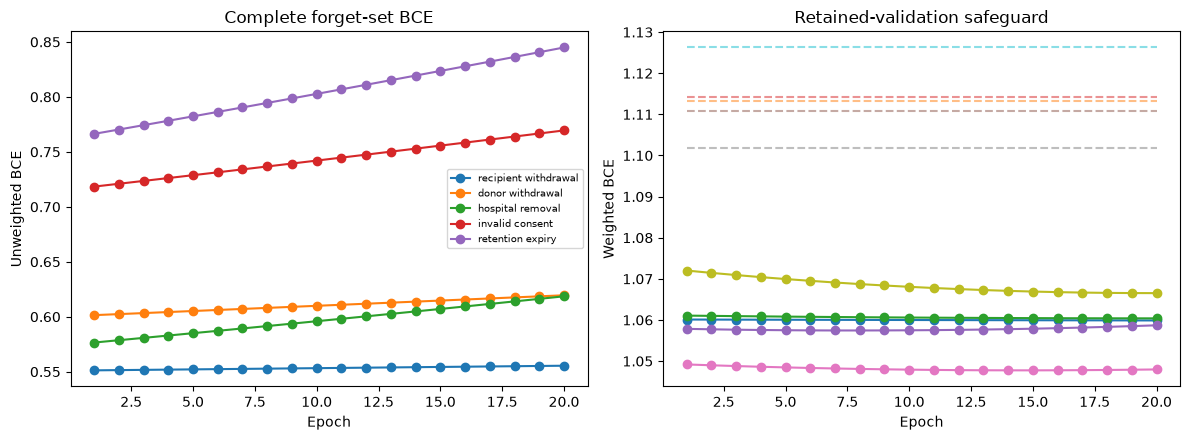

In [33]:
# Keep this training step aligned with the frozen method configuration.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for scenario in SCENARIOS:
    part = training_history.loc[training_history["scenario"].eq(scenario)]
    axes[0].plot(part["epoch"], part["complete_forget_bce"], marker="o", label=scenario.replace("_", " "))
    axes[1].plot(part["epoch"], part["retained_validation_weighted_bce"], marker="o")
    axes[1].plot(part["epoch"], part["validation_limit"], linestyle="--", alpha=.5)
axes[0].set(title="Complete forget-set BCE", xlabel="Epoch", ylabel="Unweighted BCE")
axes[1].set(title="Retained-validation safeguard", xlabel="Epoch", ylabel="Weighted BCE")
axes[0].legend(fontsize=7)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "gradient_ascent_loss_curves.png", dpi=160, bbox_inches="tight")
plt.show()


**Gradient Ascent result.**

The method finding is generated from the selected checkpoints and does not claim successful forgetting.


In [34]:
# Keep this stage separate so its inputs and checks remain easy to audit.
eligible_count = int(training_summary["eligible_updated_model"].sum())
mean_forget_change = training_summary["forget_bce_change"].mean()
display(Markdown(
    f"Gradient ascent produced an eligible updated checkpoint in **{eligible_count} of {len(SCENARIOS)}** "
    f"scenarios. Mean selected forget-set BCE change was **{mean_forget_change:+.4f}**. "
    "These are method-selection outcomes under the retained-validation guardrail; forget quality is evaluated later."
))


Gradient ascent produced an eligible updated checkpoint in **5 of 5** scenarios. Mean selected forget-set BCE change was **+0.0408**. These are method-selection outcomes under the retained-validation guardrail; forget quality is evaluated later.

# 6. Evaluate retained-data utility



The frozen threshold `0.62` and Notebook 03 metric definitions are applied to each scenario's retained test rows only after checkpoint selection.


In [35]:
# Use the fixed threshold only for threshold-dependent utility metrics.
def binary_metrics(y, probability, threshold=THRESHOLD):
    prediction = (probability >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, prediction, labels=[0, 1]).ravel()
    return {"n": len(y), "positive_count": int(y.sum()), "prevalence": float(y.mean()),
            "threshold": threshold, "pr_auc": average_precision_score(y, probability),
            "auroc": roc_auc_score(y, probability),
            "balanced_accuracy": balanced_accuracy_score(y, prediction),
            "f1": f1_score(y, prediction, zero_division=0),
            "binary_cross_entropy": log_loss(y, probability, labels=[0, 1]),
            "precision": precision_score(y, prediction, zero_division=0),
            "recall": recall_score(y, prediction, zero_division=0),
            "specificity": tn / (tn + fp), "accuracy": accuracy_score(y, prediction),
            "positive_prediction_rate": float(prediction.mean()), "true_negative": int(tn),
            "false_positive": int(fp), "false_negative": int(fn), "true_positive": int(tp)}


In [36]:
# Evaluate utility only on retained-test records after checkpoint selection.
gradient_test_frames, gradient_metric_rows = [], []
for scenario in SCENARIOS:
    frame = scenario_frames[scenario]["retained_test"].reset_index(drop=True)
    matrix, labels = scenario_matrices[scenario]["retained_test"]
    probability = predict_probabilities(gradient_models[scenario], matrix).astype(np.float64)
    gradient_test_frames.append(pd.DataFrame({"scenario": scenario,
        "evaluation_row": np.arange(len(frame)), "assessment_id": frame["assessment_id"],
        "true_target": labels.astype(int), "gradient_ascent_probability": probability,
        "gradient_ascent_prediction": (probability >= THRESHOLD).astype(int)}))
    gradient_metric_rows.append({"scenario": scenario, "model": "gradient_ascent",
                                 **binary_metrics(labels, probability)})
retained_test_predictions = pd.concat(gradient_test_frames, ignore_index=True)
gradient_metrics = pd.DataFrame(gradient_metric_rows)


The individual measures are also summarised using the existing composite utility definition.

`bce_quality = exp(-BCE)`. Composite Model Utility is the safeguarded harmonic mean of PR-AUC, AUROC, balanced accuracy, F1 and BCE quality; it supplements rather than replaces the individual metrics.


In [37]:
# Keep individual metrics visible beside the composite utility summary.
reference_utility = fine_utility.loc[fine_utility["model"].isin(["baseline", "full_retraining", "fine_tuning"])].copy()
metric_columns = list(gradient_metrics.columns)
reference_utility = reference_utility[metric_columns]
utility_metrics = pd.concat([reference_utility, gradient_metrics], ignore_index=True)
utility_metrics["bce_quality"] = np.exp(-utility_metrics["binary_cross_entropy"])
components = ["pr_auc", "auroc", "balanced_accuracy", "f1", "bce_quality"]

def harmonic(values, epsilon=1e-12):
    values = np.asarray(values, dtype=float)
    return float(len(values) / np.sum(1.0 / np.maximum(values, epsilon)))

utility_metrics["composite_model_utility"] = utility_metrics[components].apply(harmonic, axis=1)
composite_model_utility = utility_metrics[["scenario", "model", *components, "composite_model_utility"]]
assert np.allclose(composite_model_utility["composite_model_utility"],
                   composite_model_utility[components].apply(harmonic, axis=1), atol=1e-12, rtol=1e-12)


Utility is compared with the original, fine-tuned and fully retrained models.

The principal table also retains fine-tuning, using identical retained-test records within each scenario.


In [38]:
# Compare Gradient Ascent utility with each frozen reference method.
utility_pivot = utility_metrics.pivot(index="scenario", columns="model")
delta_rows = []
comparison_fields = ["pr_auc", "auroc", "balanced_accuracy", "f1",
                     "binary_cross_entropy", "bce_quality", "composite_model_utility"]
for scenario in SCENARIOS:
    row = {"scenario": scenario}
    for metric in comparison_fields:
        ascent = utility_pivot.loc[scenario, (metric, "gradient_ascent")]
        for reference in ["baseline", "full_retraining", "fine_tuning"]:
            row[f"gradient_ascent_minus_{reference}_{metric}"] = (
                ascent - utility_pivot.loc[scenario, (metric, reference)]
            )
    delta_rows.append(row)
utility_deltas = pd.DataFrame(delta_rows)
display(utility_metrics[["scenario", "model", *comparison_fields]])


,scenario,model,pr_auc,auroc,balanced_accuracy,f1,binary_cross_entropy,bce_quality,composite_model_utility
0,recipient_withdrawal,baseline,0.169267,0.731534,0.630478,0.244288,0.574755,0.562843,0.339417
1,donor_withdrawal,baseline,0.168604,0.731754,0.630475,0.244170,0.574600,0.562930,0.338853
2,hospital_removal,baseline,0.173596,0.739196,0.636655,0.252029,0.573226,0.563704,0.346601
3,invalid_consent,baseline,0.163900,0.735045,0.628857,0.237052,0.559673,0.571396,0.332878
4,retention_expiry,baseline,0.167302,0.744495,0.634281,0.252886,0.540615,0.582390,0.343208
5,recipient_withdrawal,full_retraining,0.177118,0.734572,0.628800,0.234677,0.590813,0.553877,0.340965
6,donor_withdrawal,full_retraining,0.173580,0.731609,0.633887,0.236778,0.599383,0.549150,0.338987
7,hospital_removal,full_retraining,0.176205,0.743964,0.641917,0.249229,0.590414,0.554098,0.347360
8,invalid_consent,full_retraining,0.167787,0.735362,0.637605,0.229071,0.595136,0.551488,0.331853
9,retention_expiry,full_retraining,0.162155,0.741491,0.627631,0.227008,0.585620,0.556761,0.326582


Cross-scenario results are descriptive because deletion sizes and structures differ.


In [39]:
utility_display = utility_metrics.pivot(index="scenario", columns="model",
                                        values=["composite_model_utility", "pr_auc", "f1"])
display(utility_display)


composite_model_utility                              \
model                               baseline fine_tuning full_retraining   
scenario                                                                   
donor_withdrawal                    0.338853    0.339172        0.338987   
hospital_removal                    0.346601    0.345881        0.347360   
invalid_consent                     0.332878    0.332281        0.331853   
recipient_withdrawal                0.339417    0.339028        0.340965   
retention_expiry                    0.343208    0.334213        0.326582   

                                        pr_auc                              \
model                gradient_ascent  baseline fine_tuning full_retraining   
scenario                                                                     
donor_withdrawal            0.338420  0.168604    0.168057        0.173580   
hospital_removal            0.342550  0.173596    0.172793        0.176205   
invalid_consent             0.330041  0.163900    0.163850        0.167787   
recipient_withdrawal        0.338700  0.169267    0.168471        0.177118   
retention_expiry            0.337672  0.167302    0.164546        0.162155   

                                            f1                              \
model                gradient_ascent  baseline fine_tuning full_retraining   
scenario                                                                     
donor_withdrawal            0.168852  0.244170    0.246207        0.236778   
hospital_removal            0.173381  0.252029    0.252154        0.249229   
invalid_consent             0.163250  0.237052    0.236192        0.229071   
recipient_withdrawal        0.169464  0.244288    0.245220        0.234677   
retention_expiry            0.168140  0.252886    0.238423        0.227008   

                                      
model                gradient_ascent  
scenario                              
donor_withdrawal            0.243590  
hospital_removal            0.245177  
invalid_consent             0.233417  
recipient_withdrawal        0.242476  
retention_expiry            0.240621

**Retained-data utility.**

The executed table determines whether gradient ascent preserved or damaged utility relative to each reference.


In [40]:
# Calculate the established evaluation outputs without changing model selection.
gradient_utility = utility_metrics.loc[utility_metrics["model"].eq("gradient_ascent")].set_index("scenario")
baseline_utility = utility_metrics.loc[utility_metrics["model"].eq("baseline")].set_index("scenario")
utility_change = gradient_utility["composite_model_utility"] - baseline_utility["composite_model_utility"]
best_name = utility_change.idxmax().replace("_", " ")
worst_name = utility_change.idxmin().replace("_", " ")
display(Markdown(
    f"Relative to baseline, composite utility changes ranged from **{utility_change.min():+.4f}** "
    f"({worst_name}) to **{utility_change.max():+.4f}** ({best_name}). Individual metrics remain "
    "visible in the comparison table, so the composite does not conceal the direction of its components."
))


Relative to baseline, composite utility changes ranged from **-0.0055** (retention expiry) to **-0.0004** (donor withdrawal). Individual metrics remain visible in the comparison table, so the composite does not conceal the direction of its components.

# 7. Evaluate forgetting



Baseline, full-retraining, fine-tuning and gradient-ascent probabilities, thresholded predictions and per-record BCE are aligned on the same training-forget rows.


In [41]:
# Align forgotten records before comparing probability behaviour.
# Compare every method on identical training-forget records.
def per_record_bce(labels, probability):
    probability = np.clip(np.asarray(probability, dtype=np.float64), 1e-15, 1 - 1e-15)
    labels = np.asarray(labels, dtype=np.float64)
    return -(labels * np.log(probability) + (1 - labels) * np.log(1 - probability))

forget_frames = []


In [42]:
# Calculate the established evaluation outputs without changing model selection.
for scenario in SCENARIOS:
    frame = scenario_frames[scenario]["training_forget"].reset_index(drop=True)
    matrix, labels = scenario_matrices[scenario]["training_forget"]
    full_part = full_forget.loc[full_forget["scenario"].eq(scenario)].reset_index(drop=True)
    fine_part = fine_forget.loc[fine_forget["scenario"].eq(scenario)].sort_values("evaluation_row").reset_index(drop=True)
    probabilities = {"baseline": full_part["baseline_probability"].to_numpy(dtype=np.float64),
        "full_retraining": full_part["full_retraining_probability"].to_numpy(dtype=np.float64),
        "fine_tuning": fine_part["fine_tuning_probability"].to_numpy(dtype=np.float64),
        "gradient_ascent": predict_probabilities(gradient_models[scenario], matrix).astype(np.float64)}
    output = pd.DataFrame({"scenario": scenario, "evaluation_row": np.arange(len(frame)),
                           "assessment_id": frame["assessment_id"], "true_target": labels.astype(int)})
    for method, probability in probabilities.items():
        output[f"{method}_probability"] = probability
        output[f"{method}_prediction"] = (probability >= THRESHOLD).astype(int)
        output[f"{method}_per_record_bce"] = per_record_bce(labels, probability)
    forget_frames.append(output)


In [43]:
forget_set_predictions = pd.concat(forget_frames, ignore_index=True)


Truth Ratio compares probability assigned to the incorrect and observed classes.

For binary labels, `p_true` is the probability assigned to the observed class and `p_incorrect = 1 - p_true`. The established epsilon is used unchanged.


In [44]:
# Truth Ratio compares confidence in the incorrect and true classes.
# Use the established binary Truth Ratio definition unchanged.
EPSILON = float(full_truth["epsilon"].iloc[0])
truth_frames = []
for method in ["baseline", "full_retraining", "fine_tuning", "gradient_ascent"]:
    probability = forget_set_predictions[f"{method}_probability"].to_numpy(dtype=np.float64)
    labels = forget_set_predictions["true_target"].to_numpy(dtype=np.int64)
    p_true = np.where(labels == 1, probability, 1 - probability)
    p_incorrect = 1 - p_true
    ratio = (p_incorrect + EPSILON) / (p_true + EPSILON)
    truth_frames.append(pd.DataFrame({"scenario": forget_set_predictions["scenario"],
        "evaluation_row": forget_set_predictions["evaluation_row"], "true_target": labels,
        "model": method, "p_true": p_true, "p_incorrect": p_incorrect,
        "truth_ratio": ratio, "epsilon": EPSILON}))
truth_ratio_values = pd.concat(truth_frames, ignore_index=True)


In [45]:
# Keep this stage separate so its inputs and checks remain easy to audit.
truth_ratio_summary = truth_ratio_values.groupby(["scenario", "model"])["truth_ratio"].agg(
    count="count", mean="mean", median="median", minimum="min", maximum="max",
    q1=lambda x: x.quantile(.25), q3=lambda x: x.quantile(.75)).reset_index()
truth_ratio_summary["interquartile_range"] = truth_ratio_summary["q3"] - truth_ratio_summary["q1"]
display(truth_ratio_summary)


,scenario,model,count,mean,median,minimum,maximum,q1,q3,interquartile_range
0,donor_withdrawal,baseline,1992,0.979881,0.906640,3.574875e-09,6.985770,0.390317,1.388092,0.997774
1,donor_withdrawal,fine_tuning,1992,1.015556,0.917704,3.442744e-09,7.737382,0.381329,1.430981,1.049652
2,donor_withdrawal,full_retraining,1992,1.065314,0.963850,1.271374e-07,7.135536,0.417091,1.516182,1.099091
3,donor_withdrawal,gradient_ascent,1992,1.028508,0.947777,4.375604e-09,7.630473,0.412730,1.448481,1.035751
4,hospital_removal,baseline,4314,0.935517,0.810691,1.652883e-09,8.626322,0.310622,1.343399,1.032777
5,hospital_removal,fine_tuning,4314,0.969649,0.823250,1.504561e-09,9.838072,0.309193,1.390201,1.081007
6,hospital_removal,full_retraining,4314,1.011090,0.882400,4.613736e-09,10.233602,0.308297,1.430740,1.122443
7,hospital_removal,gradient_ascent,4314,1.052714,0.899327,2.670830e-09,10.906833,0.338006,1.494859,1.156853
8,invalid_consent,baseline,4148,1.147995,0.983963,3.762437e-05,7.181721,0.678249,1.423157,0.744908
9,invalid_consent,fine_tuning,4148,1.206731,0.998091,2.901323e-05,9.602038,0.658343,1.506053,0.847710


The two-sample KS test compares gradient-ascent and full-retraining truth-ratio distributions. A higher p-value means less evidence of difference; a lower statistic means a smaller observed distance. A high p-value does not prove equivalence, erasure or privacy, and p-values depend on sample size.


In [46]:
# Keep the KS statistic beside its sample-size-sensitive p-value.
# Use the KS test to compare Gradient Ascent with full retraining.
quality_rows = []
for scenario in SCENARIOS:
    part = truth_ratio_values.loc[truth_ratio_values["scenario"].eq(scenario)]
    ascent = part.loc[part["model"].eq("gradient_ascent"), "truth_ratio"]
    full = part.loc[part["model"].eq("full_retraining"), "truth_ratio"]
    result = ks_2samp(ascent, full, alternative="two-sided", method="auto")
    quality_rows.append({"scenario": scenario, "forget_rows": len(ascent),
        "tofu_style_forget_quality": float(result.pvalue), "ks_statistic": float(result.statistic)})
forget_quality_core = pd.DataFrame(quality_rows)
display(forget_quality_core)


,scenario,forget_rows,tofu_style_forget_quality,ks_statistic
0,recipient_withdrawal,426,0.564385,0.053991
1,donor_withdrawal,1992,0.005721,0.054217
2,hospital_removal,4314,0.170908,0.023876
3,invalid_consent,4148,0.001242,0.042189
4,retention_expiry,6262,0.000100,0.039764


Supporting probability and prediction measures give context to the KS result.

Supporting measures compare gradient ascent with both full retraining and fine-tuning without replacing the KS distance.


In [47]:
# Retain supporting distances without replacing the primary KS result.
support_rows = []
for scenario in SCENARIOS:
    part = forget_set_predictions.loc[forget_set_predictions["scenario"].eq(scenario)]
    ascent, full = part["gradient_ascent_probability"], part["full_retraining_probability"]
    fine, baseline = part["fine_tuning_probability"], part["baseline_probability"]
    support_rows.append({"scenario": scenario,
        "mean_absolute_probability_difference_from_full": np.mean(np.abs(ascent - full)),
        "median_absolute_probability_difference_from_full": np.median(np.abs(ascent - full)),
        "prediction_agreement_with_full": np.mean(part["gradient_ascent_prediction"] == part["full_retraining_prediction"]),
        "mean_absolute_loss_difference_from_full": np.mean(np.abs(part["gradient_ascent_per_record_bce"] - part["full_retraining_per_record_bce"])),
        "mean_probability_change_from_baseline": np.mean(ascent - baseline),
        "prediction_changed_from_baseline_pct": 100 * np.mean(part["gradient_ascent_prediction"] != part["baseline_prediction"]),
        "mean_absolute_probability_difference_from_fine_tuning": np.mean(np.abs(ascent - fine)),
        "prediction_agreement_with_fine_tuning": np.mean(part["gradient_ascent_prediction"] == part["fine_tuning_prediction"])})
supporting_forget = pd.DataFrame(support_rows)


In [48]:
forget_quality = forget_quality_core.merge(supporting_forget, on="scenario")
display(forget_quality)


,scenario,forget_rows,tofu_style_forget_quality,ks_statistic,mean_absolute_probability_difference_from_full,median_absolute_probability_difference_from_full,prediction_agreement_with_full,mean_absolute_loss_difference_from_full,mean_probability_change_from_baseline,prediction_changed_from_baseline_pct,mean_absolute_probability_difference_from_fine_tuning,prediction_agreement_with_fine_tuning
0,recipient_withdrawal,426,0.564385,0.053991,0.022331,0.014035,0.957746,0.047408,0.002653,0.938967,0.005572,0.995305
1,donor_withdrawal,1992,0.005721,0.054217,0.021322,0.016402,0.945783,0.045953,0.009750,2.610442,0.005803,0.992470
2,hospital_removal,4314,0.170908,0.023876,0.025392,0.018820,0.934863,0.055900,0.023252,5.586463,0.018114,0.958044
3,invalid_consent,4148,0.001242,0.042189,0.030092,0.025295,0.932498,0.066335,0.028830,6.798457,0.023009,0.965043
4,retention_expiry,6262,0.000100,0.039764,0.041035,0.034542,0.887256,0.096188,0.041451,10.380070,0.032107,0.932609


KS distances are compared across the five predefined scenarios.

KS statistic is the principal cross-scenario distance because p-values are strongly affected by unequal forget-set sizes.


In [49]:
# Keep this stage separate so its inputs and checks remain easy to audit.
fine_ks = fine_quality[["scenario", "ks_statistic"]].rename(columns={"ks_statistic": "fine_tuning_ks_statistic"})
forget_comparison = forget_quality.merge(fine_ks, on="scenario")
forget_comparison["gradient_minus_fine_ks_statistic"] = (
    forget_comparison["ks_statistic"] - forget_comparison["fine_tuning_ks_statistic"]
)
display(forget_comparison[["scenario", "forget_rows", "ks_statistic",
                           "fine_tuning_ks_statistic", "gradient_minus_fine_ks_statistic",
                           "tofu_style_forget_quality"]])


,scenario,forget_rows,ks_statistic,fine_tuning_ks_statistic,gradient_minus_fine_ks_statistic,tofu_style_forget_quality
0,recipient_withdrawal,426,0.053991,0.044601,0.009390,0.564385
1,donor_withdrawal,1992,0.054217,0.057229,-0.003012,0.005721
2,hospital_removal,4314,0.023876,0.042188,-0.018312,0.170908
3,invalid_consent,4148,0.042189,0.036644,0.005545,0.001242
4,retention_expiry,6262,0.039764,0.041520,-0.001757,0.000100


**Forget-set results.**

The following finding reports executed KS values and explicitly avoids using them to revise training settings.


In [50]:
# Keep this stage separate so its inputs and checks remain easy to audit.
detectable = forget_comparison.loc[forget_comparison["tofu_style_forget_quality"].lt(.05), "scenario"]
better_than_fine = forget_comparison.loc[forget_comparison["gradient_minus_fine_ks_statistic"].lt(0), "scenario"]
ks_lines = [f"{row.scenario.replace('_', ' ')}: KS={row.ks_statistic:.4f}, p={row.tofu_style_forget_quality:.4g}"
            for row in forget_comparison.itertuples()]
display(Markdown(
    "Gradient-ascent versus full-retraining truth-ratio results were: " + "; ".join(ks_lines) + ". "
    f"A difference was detectable at p<0.05 in **{len(detectable)}** scenarios, and gradient ascent had "
    f"a lower KS distance than fine-tuning in **{len(better_than_fine)}** scenarios. These results did not alter the fixed settings."
))


Gradient-ascent versus full-retraining truth-ratio results were: recipient withdrawal: KS=0.0540, p=0.5644; donor withdrawal: KS=0.0542, p=0.005721; hospital removal: KS=0.0239, p=0.1709; invalid consent: KS=0.0422, p=0.001242; retention expiry: KS=0.0398, p=0.0001001. A difference was detectable at p<0.05 in **3** scenarios, and gradient ascent had a lower KS distance than fine-tuning in **3** scenarios. These results did not alter the fixed settings.

# 8. Compare with fine-tuning and full retraining



Measured gradient-ascent time is compared with saved reference times. `MEANINGFUL_SPEEDUP = 1.10` is a descriptive threshold for noisy wall-clock timing only and cannot affect model selection or scientific metrics.


In [51]:
# Compare saved training-phase timings on their recorded scopes.
efficiency = training_summary[["scenario", "training_seconds"]].rename(
    columns={"training_seconds": "training_seconds_gradient_ascent"}
).merge(fine_training[["scenario", "training_seconds"]].rename(
    columns={"training_seconds": "training_seconds_fine_tuning"}), on="scenario"
).merge(full_training[["scenario", "training_seconds"]].rename(
    columns={"training_seconds": "training_seconds_full_retraining"}), on="scenario")
for reference in ["fine_tuning", "full_retraining"]:
    efficiency[f"speed_up_vs_{reference}"] = (
        efficiency[f"training_seconds_{reference}"] / efficiency["training_seconds_gradient_ascent"]
    )
    efficiency[f"time_reduction_pct_vs_{reference}"] = 100 * (
        efficiency[f"training_seconds_{reference}"] - efficiency["training_seconds_gradient_ascent"]
    ) / efficiency[f"training_seconds_{reference}"]
display(efficiency)


,scenario,training_seconds_gradient_ascent,training_seconds_fine_tuning,training_seconds_full_retraining,speed_up_vs_fine_tuning,time_reduction_pct_vs_fine_tuning,speed_up_vs_full_retraining,time_reduction_pct_vs_full_retraining
0,recipient_withdrawal,0.082731,0.961513,3.923029,11.622219,91.395791,47.419328,97.891155
1,donor_withdrawal,0.164424,1.012794,3.450068,6.159653,83.765319,20.982773,95.234186
2,hospital_removal,0.308786,0.908232,3.847863,2.941296,66.001386,12.461245,91.975119
3,invalid_consent,0.370443,1.373795,3.528170,3.708520,73.035067,9.524190,89.500420
4,retention_expiry,0.454323,3.194244,3.111061,7.030772,85.776811,6.847679,85.396512


In [52]:
# This threshold describes noisy wall-clock timing only.
MEANINGFUL_SPEEDUP = 1.10

def runtime_interpretation(speed_up):
    if speed_up >= MEANINGFUL_SPEEDUP:
        return "meaningfully faster"
    if speed_up > 1:
        return "slightly faster, with no meaningful advantage"
    if np.isclose(speed_up, 1, atol=0.01):
        return "approximately equal"
    return "slower"

runtime_lines = []


In [53]:
# Keep this stage separate so its inputs and checks remain easy to audit.
for row in efficiency.itertuples():
    full_text = runtime_interpretation(row.speed_up_vs_full_retraining)
    fine_text = runtime_interpretation(row.speed_up_vs_fine_tuning)
    runtime_lines.append(
        f"- **{row.scenario.replace('_', ' ').capitalize()}**: {row.training_seconds_gradient_ascent:.2f}s; "
        f"{row.speed_up_vs_full_retraining:.2f}× versus full retraining ({full_text}); "
        f"{row.speed_up_vs_fine_tuning:.2f}× versus fine-tuning ({fine_text})."
    )
runtime_summary = "\n".join(runtime_lines)
display(Markdown(runtime_summary))


- **Recipient withdrawal**: 0.08s; 47.42× versus full retraining (meaningfully faster); 11.62× versus fine-tuning (meaningfully faster).
- **Donor withdrawal**: 0.16s; 20.98× versus full retraining (meaningfully faster); 6.16× versus fine-tuning (meaningfully faster).
- **Hospital removal**: 0.31s; 12.46× versus full retraining (meaningfully faster); 2.94× versus fine-tuning (meaningfully faster).
- **Invalid consent**: 0.37s; 9.52× versus full retraining (meaningfully faster); 3.71× versus fine-tuning (meaningfully faster).
- **Retention expiry**: 0.45s; 6.85× versus full retraining (meaningfully faster); 7.03× versus fine-tuning (meaningfully faster).

Utility and forget-distribution distance are plotted without combining them into one score.

Composite utility is on the x-axis and KS statistic on the y-axis, where lower is closer to full retraining. Distinct markers separate gradient ascent and fine-tuning; p-value is not used as a cross-scenario axis.


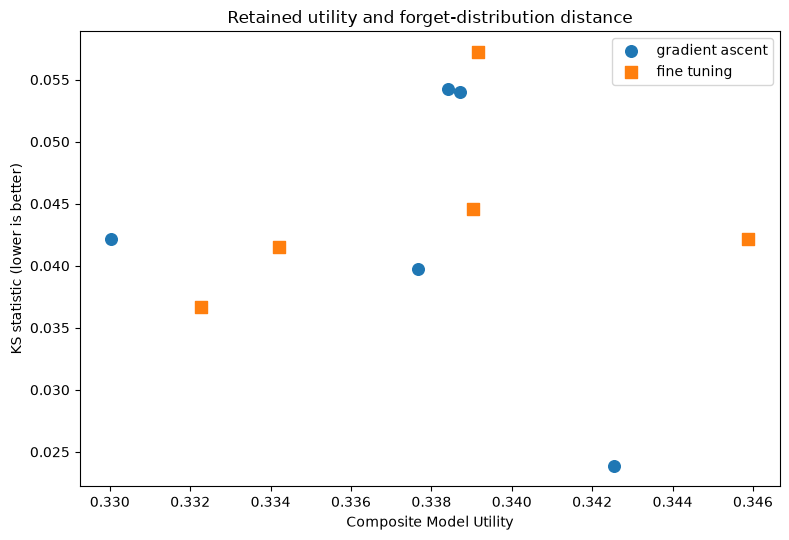

In [54]:
# Plot retained utility and forgetting as separate dimensions.
gradient_trade = composite_model_utility.loc[
    composite_model_utility["model"].eq("gradient_ascent"), ["scenario", "composite_model_utility"]
].merge(forget_quality_core[["scenario", "ks_statistic"]], on="scenario").assign(method="gradient ascent")
fine_trade = composite_model_utility.loc[
    composite_model_utility["model"].eq("fine_tuning"), ["scenario", "composite_model_utility"]
].merge(fine_quality[["scenario", "ks_statistic"]], on="scenario").assign(method="fine tuning")
trade_plot = pd.concat([gradient_trade, fine_trade], ignore_index=True)
fig, ax = plt.subplots(figsize=(8, 5.5))
for method, marker in [("gradient ascent", "o"), ("fine tuning", "s")]:
    part = trade_plot.loc[trade_plot["method"].eq(method)]
    ax.scatter(part["composite_model_utility"], part["ks_statistic"], marker=marker, s=70, label=method)
ax.set(xlabel="Composite Model Utility", ylabel="KS statistic (lower is better)",
       title="Retained utility and forget-distribution distance")
ax.legend()
fig.tight_layout()


In [55]:
fig.savefig(FIGURE_DIR / "utility_vs_forget_distance.png", dpi=160, bbox_inches="tight")
plt.show()


The final comparison keeps utility, forgetting and efficiency separate.

The combined table keeps all three dimensions separate; it does not create an arbitrary overall score.


In [56]:
# Keep this stage separate so its inputs and checks remain easy to audit.
gradient_composite = composite_model_utility.loc[
    composite_model_utility["model"].eq("gradient_ascent"),
    ["scenario", "pr_auc", "auroc", "balanced_accuracy", "f1", "bce_quality", "composite_model_utility"]
]
combined_tradeoff = gradient_composite.merge(forget_comparison, on="scenario").merge(efficiency, on="scenario")
display(combined_tradeoff)


,scenario,pr_auc,auroc,balanced_accuracy,f1,bce_quality,composite_model_utility,forget_rows,tofu_style_forget_quality,ks_statistic,...,prediction_agreement_with_fine_tuning,fine_tuning_ks_statistic,gradient_minus_fine_ks_statistic,training_seconds_gradient_ascent,training_seconds_fine_tuning,training_seconds_full_retraining,speed_up_vs_fine_tuning,time_reduction_pct_vs_fine_tuning,speed_up_vs_full_retraining,time_reduction_pct_vs_full_retraining
0,recipient_withdrawal,0.169464,0.731559,0.630736,0.242476,0.560269,0.338700,426,0.564385,0.053991,...,0.995305,0.044601,0.009390,0.082731,0.961513,3.923029,11.622219,91.395791,47.419328,97.891155
1,donor_withdrawal,0.168852,0.731938,0.636227,0.243590,0.552815,0.338420,1992,0.005721,0.054217,...,0.992470,0.057229,-0.003012,0.164424,1.012794,3.450068,6.159653,83.765319,20.982773,95.234186
2,hospital_removal,0.173381,0.739253,0.647132,0.245177,0.539940,0.342550,4314,0.170908,0.023876,...,0.958044,0.042188,-0.018312,0.308786,0.908232,3.847863,2.941296,66.001386,12.461245,91.975119
3,invalid_consent,0.163250,0.735654,0.641702,0.233417,0.548788,0.330041,4148,0.001242,0.042189,...,0.965043,0.036644,0.005545,0.370443,1.373795,3.528170,3.708520,73.035067,9.524190,89.500420
4,retention_expiry,0.168140,0.745278,0.646564,0.240621,0.550805,0.337672,6262,0.000100,0.039764,...,0.932609,0.041520,-0.001757,0.454323,3.194244,3.111061,7.030772,85.776811,6.847679,85.396512


**Efficiency and trade-offs.**

Runtime and trade-off wording is generated from the current tables; no runtime or outcome is hard-coded.


In [57]:
# Keep this stage separate so its inputs and checks remain easy to audit.
utility_mean = gradient_composite["composite_model_utility"].mean()
ks_mean = forget_comparison["ks_statistic"].mean()
full_advantage = int((efficiency["speed_up_vs_full_retraining"] >= MEANINGFUL_SPEEDUP).sum())
fine_advantage = int((efficiency["speed_up_vs_fine_tuning"] >= MEANINGFUL_SPEEDUP).sum())
section_7_finding = (
    f"Mean gradient-ascent composite utility was **{utility_mean:.4f}** and mean KS distance was "
    f"**{ks_mean:.4f}**. Gradient ascent was meaningfully faster than full retraining in "
    f"**{full_advantage}** scenarios and meaningfully faster than fine-tuning in **{fine_advantage}** scenarios.\n\n"
    + runtime_summary + "\n\nRuntime is hardware-dependent. Utility, forgetting and efficiency remain separate."
)
display(Markdown(section_7_finding))


Mean gradient-ascent composite utility was **0.3375** and mean KS distance was **0.0428**. Gradient ascent was meaningfully faster than full retraining in **5** scenarios and meaningfully faster than fine-tuning in **5** scenarios.

- **Recipient withdrawal**: 0.08s; 47.42× versus full retraining (meaningfully faster); 11.62× versus fine-tuning (meaningfully faster).
- **Donor withdrawal**: 0.16s; 20.98× versus full retraining (meaningfully faster); 6.16× versus fine-tuning (meaningfully faster).
- **Hospital removal**: 0.31s; 12.46× versus full retraining (meaningfully faster); 2.94× versus fine-tuning (meaningfully faster).
- **Invalid consent**: 0.37s; 9.52× versus full retraining (meaningfully faster); 3.71× versus fine-tuning (meaningfully faster).
- **Retention expiry**: 0.45s; 6.85× versus full retraining (meaningfully faster); 7.03× versus fine-tuning (meaningfully faster).

Runtime is hardware-dependent. Utility, forgetting and efficiency remain separate.

# 9. Save and verify artefacts



Five selected checkpoints and five transparent configurations are saved. Configurations reference the frozen baseline preprocessor rather than duplicating it.


In [58]:
# Save exactly the selected checkpoint for each scenario.
for scenario, model in gradient_models.items():
    row = training_summary.set_index("scenario").loc[scenario]
    checkpoint = {"model_state_dict": model.state_dict(), "input_dim": 24,
        "hidden_dims": [64, 32], "dropout": 0.10, "scenario": scenario,
        "selected_epoch": int(row["selected_epoch"]), "threshold": THRESHOLD, "seed": SEED}
    torch.save(checkpoint, MODEL_DIR / f"{scenario}_model.pt")
    configuration = {"scenario": scenario, "method": "gradient_ascent",
        "baseline_source": "models/baseline/baseline_model.pt",
        "preprocessor_source": "models/baseline/baseline_preprocessor.joblib",
        "classifier_features": classifier_features, "architecture": [24, 64, 32, 1],
        "parameter_count": 3713, "optimizer": "AdamW", "learning_rate": ASCENT_LEARNING_RATE,
        "weight_decay": 0, "batch_size": BATCH_SIZE, "maximum_epochs": MAX_ASCENT_EPOCHS,
        "safety_patience": SAFETY_PATIENCE, "gradient_clip_norm": GRADIENT_CLIP_NORM,
        "validation_relative_allowance": VALIDATION_RELATIVE_ALLOWANCE,
        "selected_epoch": int(row["selected_epoch"]), "eligible_updated_model": bool(row["eligible_updated_model"]),
        "threshold": THRESHOLD, "seed": SEED, "training_seconds": float(row["training_seconds"])}
    (MODEL_DIR / f"{scenario}_configuration.json").write_text(json.dumps(configuration, indent=2) + "\n")


Saved tables and checkpoints are reloaded and checked independently.

Persisted CSVs are independently read back. Truth ratios, KS results, models, both probability sets, configurations, scenario coverage, threshold, leakage protections and protected hashes are then checked in separate focused cells.


In [59]:
# Persist the tables required for verification and later comparisons.
outputs = {
    "training_history.csv": training_history, "training_summary.csv": training_summary,
    "retained_test_predictions.csv": retained_test_predictions, "utility_metrics.csv": utility_metrics,
    "composite_model_utility.csv": composite_model_utility, "utility_deltas.csv": utility_deltas,
    "forget_set_predictions.csv": forget_set_predictions, "truth_ratio_values.csv": truth_ratio_values,
    "truth_ratio_summary.csv": truth_ratio_summary, "forget_quality.csv": forget_comparison,
    "efficiency_comparison.csv": efficiency, "combined_tradeoff.csv": combined_tradeoff,
}
for name, frame in outputs.items():
    frame.to_csv(RESULT_DIR / name, index=False, float_format="%.17g")


In [60]:
# Read every saved table back before final acceptance.
saved = {name: pd.read_csv(RESULT_DIR / name) for name in outputs}
csv_readback_checks = pd.DataFrame([
    {"artifact": name, "rows_match": len(saved[name]) == len(frame),
     "columns_match": list(saved[name].columns) == list(frame.columns)}
    for name, frame in outputs.items()
])
csv_readback_pass = bool(csv_readback_checks[["rows_match", "columns_match"]].to_numpy().all())
display(csv_readback_checks)
assert csv_readback_pass


,artifact,rows_match,columns_match
0,training_history.csv,True,True
1,training_summary.csv,True,True
2,retained_test_predictions.csv,True,True
3,utility_metrics.csv,True,True
4,composite_model_utility.csv,True,True
5,utility_deltas.csv,True,True
6,forget_set_predictions.csv,True,True
7,truth_ratio_values.csv,True,True
8,truth_ratio_summary.csv,True,True
9,forget_quality.csv,True,True


**Independent metric reproduction.**

Row-and-column readback is necessary but not sufficient. The saved gradient-ascent probabilities and true targets are now used to independently recalculate every retained-test metric at the frozen threshold `0.62`. BCE quality and Composite Model Utility are then reconstructed from those recalculated values rather than trusted from the saved metric tables.


In [61]:
# Recalculate utility from the saved probabilities and targets.
saved_utility = saved["utility_metrics.csv"]
saved_test_predictions = saved["retained_test_predictions.csv"]
metric_names = [
    "n", "positive_count", "prevalence", "pr_auc", "auroc",
    "balanced_accuracy", "f1", "binary_cross_entropy", "precision",
    "recall", "specificity", "accuracy", "positive_prediction_rate",
    "true_negative", "false_positive", "false_negative", "true_positive",
]
exact_metrics = {"n", "positive_count", "true_negative", "false_positive",
                 "false_negative", "true_positive"}
utility_reproduction_rows = []
recalculated_by_scenario = {}


In [62]:
# Calculate the established evaluation outputs without changing model selection.
for scenario in SCENARIOS:
    frame = saved_test_predictions.loc[saved_test_predictions["scenario"].eq(scenario)]
    recalculated = binary_metrics(
        frame["true_target"].to_numpy(),
        frame["gradient_ascent_probability"].to_numpy(dtype=np.float64),
        THRESHOLD,
    )
    recalculated_by_scenario[scenario] = recalculated
    saved_row = saved_utility.loc[
        saved_utility["scenario"].eq(scenario)
        & saved_utility["model"].eq("gradient_ascent")
    ].iloc[0]
    for metric in metric_names:
        tolerance = 0.0 if metric in exact_metrics else 1e-8
        difference = abs(float(saved_row[metric]) - float(recalculated[metric]))
        utility_reproduction_rows.append({
            "scenario": scenario, "metric": metric,
            "saved_value": float(saved_row[metric]),
            "recalculated_value": float(recalculated[metric]),
            "absolute_difference": difference, "required_tolerance": tolerance,
            "pass": bool(difference <= tolerance),
        })


In [63]:
utility_metric_reproduction = pd.DataFrame(utility_reproduction_rows)


In [64]:
# Reproduce composite utility from independently recalculated components.
saved_composite = saved["composite_model_utility.csv"]
composite_rows = []


In [65]:
# Calculate the established evaluation outputs without changing model selection.
for scenario in SCENARIOS:
    recalculated = recalculated_by_scenario[scenario]
    bce_quality = float(np.exp(-recalculated["binary_cross_entropy"]))
    composite = harmonic([
        recalculated["pr_auc"], recalculated["auroc"],
        recalculated["balanced_accuracy"], recalculated["f1"], bce_quality,
    ])
    saved_row = saved_composite.loc[
        saved_composite["scenario"].eq(scenario)
        & saved_composite["model"].eq("gradient_ascent")
    ].iloc[0]
    for metric, recalculated_value in [
        ("bce_quality", bce_quality),
        ("composite_model_utility", composite),
    ]:
        difference = abs(float(saved_row[metric]) - recalculated_value)
        composite_rows.append({
            "scenario": scenario, "metric": metric,
            "saved_value": float(saved_row[metric]),
            "recalculated_value": recalculated_value,
            "absolute_difference": difference, "required_tolerance": 1e-8,
            "pass": bool(difference <= 1e-8),
        })


In [66]:
# Append composite-utility reproduction to the metric audit.
utility_metric_reproduction = pd.concat([
    utility_metric_reproduction, pd.DataFrame(composite_rows)
], ignore_index=True)
utility_metric_reproduction.to_csv(
    RESULT_DIR / "utility_metric_reproduction.csv", index=False, float_format="%.17g"
)
utility_metric_reproduction_pass = bool(
    utility_metric_reproduction.loc[~utility_metric_reproduction["metric"].isin(
        ["bce_quality", "composite_model_utility"]
    ), "pass"].all()
)


In [67]:
# Fail early if this stage no longer matches the frozen experiment contract.
composite_utility_reproduction_pass = bool(
    utility_metric_reproduction.loc[utility_metric_reproduction["metric"].isin(
        ["bce_quality", "composite_model_utility"]
    ), "pass"].all()
)
utility_reproduction_summary = utility_metric_reproduction.groupby("scenario")["pass"].all().reset_index()
display(utility_reproduction_summary)
assert utility_metric_reproduction_pass and composite_utility_reproduction_pass


,scenario,pass
0,donor_withdrawal,True
1,hospital_removal,True
2,invalid_consent,True
3,recipient_withdrawal,True
4,retention_expiry,True


In [68]:
# Reproduce Truth Ratio from its persisted probability components.
saved_truth = saved["truth_ratio_values.csv"]
reproduced_ratio = ((saved_truth["p_incorrect"] + saved_truth["epsilon"])
                    / (saved_truth["p_true"] + saved_truth["epsilon"]))
ratio_difference = np.abs(saved_truth["truth_ratio"] - reproduced_ratio)
truth_ratio_reproduction_pass = bool(np.allclose(
    saved_truth["truth_ratio"], reproduced_ratio, atol=1e-8, rtol=0
))
truth_ratio_diagnostic = pd.DataFrame([{"rows": len(saved_truth),
    "maximum_absolute_difference": float(ratio_difference.max()),
    "required_tolerance": 1e-8, "pass": truth_ratio_reproduction_pass}])
truth_ratio_diagnostic.to_csv(RESULT_DIR / "truth_ratio_reproduction_diagnostic.csv",
                              index=False, float_format="%.17g")
display(truth_ratio_diagnostic)
assert truth_ratio_reproduction_pass


,rows,maximum_absolute_difference,required_tolerance,pass
0,68568,1.065814e-14,1.000000e-08,True


In [69]:
# Reproduce every saved KS statistic and p-value.
saved_quality = saved["forget_quality.csv"].set_index("scenario")
ks_rows = []
for scenario in SCENARIOS:
    part = saved_truth.loc[saved_truth["scenario"].eq(scenario)]
    result = ks_2samp(part.loc[part["model"].eq("gradient_ascent"), "truth_ratio"],
                      part.loc[part["model"].eq("full_retraining"), "truth_ratio"])
    ks_rows.append({"scenario": scenario,
        "statistic_pass": np.isclose(result.statistic, saved_quality.loc[scenario, "ks_statistic"], atol=1e-12, rtol=1e-12),
        "pvalue_pass": np.isclose(result.pvalue, saved_quality.loc[scenario, "tofu_style_forget_quality"], atol=1e-12, rtol=1e-12)})
ks_reproduction = pd.DataFrame(ks_rows)
ks_reproduction_pass = bool(ks_reproduction[["statistic_pass", "pvalue_pass"]].to_numpy().all())
display(ks_reproduction)
assert ks_reproduction_pass


,scenario,statistic_pass,pvalue_pass
0,recipient_withdrawal,True,True
1,donor_withdrawal,True,True
2,hospital_removal,True,True
3,invalid_consent,True,True
4,retention_expiry,True,True


In [70]:
# Reload every model and reproduce both retained and forget probabilities.
reload_rows = []


In [71]:
# Calculate the established evaluation outputs without changing model selection.
for scenario in SCENARIOS:
    checkpoint = load_checkpoint(MODEL_DIR / f"{scenario}_model.pt")
    configuration = json.loads((MODEL_DIR / f"{scenario}_configuration.json").read_text())
    reloaded = BaselineMLP(checkpoint["input_dim"], tuple(checkpoint["hidden_dims"]), checkpoint["dropout"])
    reloaded.load_state_dict(checkpoint["model_state_dict"])
    test_probability = predict_probabilities(reloaded, scenario_matrices[scenario]["retained_test"][0]).astype(np.float64)
    forget_probability = predict_probabilities(reloaded, scenario_matrices[scenario]["training_forget"][0]).astype(np.float64)
    saved_test = saved["retained_test_predictions.csv"].loc[
        saved["retained_test_predictions.csv"]["scenario"].eq(scenario), "gradient_ascent_probability"].to_numpy()
    saved_forget = saved["forget_set_predictions.csv"].loc[
        saved["forget_set_predictions.csv"]["scenario"].eq(scenario), "gradient_ascent_probability"].to_numpy()
    metadata_pass = (checkpoint["scenario"] == configuration["scenario"] == scenario
        and checkpoint["threshold"] == configuration["threshold"] == THRESHOLD
        and configuration["architecture"] == [24, 64, 32, 1]
        and configuration["classifier_features"] == classifier_features
        and configuration["parameter_count"] == 3_713)
    reload_rows.append({"scenario": scenario,
        "retained_test_max_abs_difference": float(np.max(np.abs(test_probability - saved_test))),
        "training_forget_max_abs_difference": float(np.max(np.abs(forget_probability - saved_forget))),
        "retained_test_probability_pass": np.allclose(test_probability, saved_test, atol=1e-8, rtol=1e-8),
        "training_forget_probability_pass": np.allclose(forget_probability, saved_forget, atol=1e-8, rtol=1e-8),
        "configuration_pass": metadata_pass})


In [72]:
# Fail early if this stage no longer matches the frozen experiment contract.
model_reload_verification = pd.DataFrame(reload_rows)
model_reload_verification.to_csv(RESULT_DIR / "model_reload_verification.csv", index=False, float_format="%.17g")
model_reload_pass = bool(model_reload_verification.filter(like="pass").to_numpy().all())
display(model_reload_verification)
assert model_reload_pass


,scenario,retained_test_max_abs_difference,training_forget_max_abs_difference,retained_test_probability_pass,training_forget_probability_pass,configuration_pass
0,recipient_withdrawal,1.110223e-16,1.110223e-16,True,True,True
1,donor_withdrawal,1.110223e-16,1.110223e-16,True,True,True
2,hospital_removal,1.110223e-16,2.220446e-16,True,True,True
3,invalid_consent,1.110223e-16,1.110223e-16,True,True,True
4,retention_expiry,1.110223e-16,2.220446e-16,True,True,True


In [73]:
# Confirm saved configurations retain the reviewed ascent settings.
configuration_checks = pd.DataFrame([
    {"scenario": scenario, "pass": (
        json.loads((MODEL_DIR / f"{scenario}_configuration.json").read_text())["learning_rate"] == ASCENT_LEARNING_RATE
        and json.loads((MODEL_DIR / f"{scenario}_configuration.json").read_text())["maximum_epochs"] == MAX_ASCENT_EPOCHS
        and json.loads((MODEL_DIR / f"{scenario}_configuration.json").read_text())["validation_relative_allowance"] == VALIDATION_RELATIVE_ALLOWANCE
    )} for scenario in SCENARIOS
])
configuration_pass = bool(configuration_checks["pass"].all())
display(configuration_checks)
assert configuration_pass


,scenario,pass
0,recipient_withdrawal,True
1,donor_withdrawal,True
2,hospital_removal,True
3,invalid_consent,True
4,retention_expiry,True


In [74]:
# Confirm scenario coverage and the frozen threshold.
saved_utility = saved["utility_metrics.csv"]
saved_test_predictions = saved["retained_test_predictions.csv"]
saved_forget_predictions = saved["forget_set_predictions.csv"]
scenario_threshold_checks = pd.DataFrame([
    {"check": "all scenarios", "pass": set(saved_test_predictions["scenario"]) == set(SCENARIOS)},
    {"check": "threshold remains 0.62", "pass": THRESHOLD == 0.62 and np.allclose(saved_utility["threshold"], THRESHOLD)},
    {"check": "retained-test counts", "pass": len(saved_test_predictions) == sum(len(scenario_frames[s]["retained_test"]) for s in SCENARIOS)},
    {"check": "training-forget counts", "pass": len(saved_forget_predictions) == sum(EXPECTED_FORGET_COUNTS.values())},
])
scenario_threshold_pass = bool(scenario_threshold_checks["pass"].all())
display(scenario_threshold_checks)
assert scenario_threshold_pass


,check,pass
0,all scenarios,True
1,threshold remains 0.62,True
2,retained-test counts,True
3,training-forget counts,True


In [75]:
# Ensure identity and audit fields never become model inputs.
leakage_checks = pd.DataFrame([
    {"check": "classifier contract excludes identifiers and audit fields",
     "pass": direct_identity_fields.isdisjoint(classifier_features)},
    {"check": "retained-test output excludes identity attributes",
     "pass": {"full_name", "date_of_birth", "email_address", "postcode", "hospital_number"}.isdisjoint(saved_test_predictions.columns)},
    {"check": "forget output excludes identity attributes",
     "pass": {"full_name", "date_of_birth", "email_address", "postcode", "hospital_number"}.isdisjoint(saved_forget_predictions.columns)},
])
leakage_pass = bool(leakage_checks["pass"].all())
display(leakage_checks)
assert leakage_pass


,check,pass
0,classifier contract excludes identifiers and a...,True
1,retained-test output excludes identity attributes,True
2,forget output excludes identity attributes,True


In [76]:
# Require every model, table and figure before accepting the run.
required_files = [RESULT_DIR / name for name in outputs] + [
    RESULT_DIR / "truth_ratio_reproduction_diagnostic.csv",
    RESULT_DIR / "utility_metric_reproduction.csv",
    RESULT_DIR / "model_reload_verification.csv",
    FIGURE_DIR / "gradient_ascent_loss_curves.png",
    FIGURE_DIR / "utility_vs_forget_distance.png",
]
required_files += [MODEL_DIR / f"{scenario}_{suffix}" for scenario in SCENARIOS
                   for suffix in ("model.pt", "configuration.json")]
required_artifacts_pass = all(path.is_file() for path in required_files)
assert required_artifacts_pass
print(f"Required artifacts present: {len(required_files)}")


Required artifacts present: 27


In [77]:
# Confirm that every protected input remains byte-identical.
input_hashes_after = {path.relative_to(ROOT).as_posix(): sha256(path) for path in protected_paths}
input_hashes_unchanged = input_hashes_before == input_hashes_after
hash_check = pd.DataFrame([
    {"protected_input": name, "before_sha256": digest,
     "after_sha256": input_hashes_after[name], "unchanged": digest == input_hashes_after[name]}
    for name, digest in input_hashes_before.items()
])
display(hash_check)
assert input_hashes_unchanged


,protected_input,before_sha256,after_sha256,unchanged
0,data/final/kidney_transplant_assessments.csv,ec6c6265fc7ed7674c2950316efefb74546b04a817e37f...,ec6c6265fc7ed7674c2950316efefb74546b04a817e37f...,True
1,data/final/classifier_feature_list.json,9fd5fde0ac22707a8dd9f5fe11da688aba8bca9a95b630...,9fd5fde0ac22707a8dd9f5fe11da688aba8bca9a95b630...,True
2,processed_data/split_assignments.csv,fde3ab5bfd16abb18191b4b10619f2d1a651006896325c...,fde3ab5bfd16abb18191b4b10619f2d1a651006896325c...,True
3,processed_data/deletion_scenario_membership.csv,76ba6f3fb6a919352f51d4db636875a242a25440e088fd...,76ba6f3fb6a919352f51d4db636875a242a25440e088fd...,True
4,models/baseline/baseline_model.pt,f91581e9ed02593c50b6ce538791f8b7fb2bb23361ede1...,f91581e9ed02593c50b6ce538791f8b7fb2bb23361ede1...,True
5,models/baseline/baseline_preprocessor.joblib,e93f3d0249e457e57575f40182f7b2647653794ea3dba8...,e93f3d0249e457e57575f40182f7b2647653794ea3dba8...,True
6,results/full_retraining/figures/full_retrainin...,1bfe0212e5453d33c945359c6d4c785a7fa2cabc571dcf...,1bfe0212e5453d33c945359c6d4c785a7fa2cabc571dcf...,True
7,results/full_retraining/figures/full_retrainin...,d57ef44e0bcdb368c47eec8963eb74d959124284da59ff...,d57ef44e0bcdb368c47eec8963eb74d959124284da59ff...,True
8,results/full_retraining/forget_set_reference_p...,857f9d58d2c81437b784379e287ffa444d5c24695780ad...,857f9d58d2c81437b784379e287ffa444d5c24695780ad...,True
9,results/full_retraining/metric_reproduction_di...,6f968227013aba608ce9bedd38235ccc681a1a5c476327...,6f968227013aba608ce9bedd38235ccc681a1a5c476327...,True


In [78]:
# Require every verification group to pass before completion.
acceptance = pd.DataFrame([
    {"requirement": "Input compatibility", "pass": bool(artifact_checks["passed"].all())},
    {"requirement": "CSV readback", "pass": csv_readback_pass},
    {"requirement": "Independent retained-utility reproduction",
     "pass": utility_metric_reproduction_pass and composite_utility_reproduction_pass},
    {"requirement": "Truth-ratio reproduction", "pass": truth_ratio_reproduction_pass},
    {"requirement": "KS reproduction", "pass": ks_reproduction_pass},
    {"requirement": "Five model and probability reloads", "pass": model_reload_pass},
    {"requirement": "Configurations, scenarios and threshold", "pass": configuration_pass and scenario_threshold_pass},
    {"requirement": "Leakage and required artifacts", "pass": leakage_pass and required_artifacts_pass},
    {"requirement": "Protected inputs and Notebooks 00–03 unchanged", "pass": input_hashes_unchanged},
])
acceptance["status"] = acceptance["pass"].map({True: "PASS", False: "FAIL"})
display(acceptance.drop(columns="pass"))
assert bool(acceptance["pass"].all())


,requirement,status
0,Input compatibility,PASS
1,CSV readback,PASS
2,Independent retained-utility reproduction,PASS
3,Truth-ratio reproduction,PASS
4,KS reproduction,PASS
5,Five model and probability reloads,PASS
6,"Configurations, scenarios and threshold",PASS
7,Leakage and required artifacts,PASS
8,Protected inputs and Notebooks 00–03 unchanged,PASS


In [79]:
# Write completed status only after the acceptance assertion succeeds.
run_summary = {"status": "completed", "task": "gradient ascent", "seed": SEED,
    "threshold": THRESHOLD, "scenario_count": len(SCENARIOS), "scenarios": SCENARIOS,
    "configuration": {"optimizer": "AdamW", "learning_rate": ASCENT_LEARNING_RATE,
        "weight_decay": 0, "batch_size": BATCH_SIZE, "maximum_epochs": MAX_ASCENT_EPOCHS,
        "safety_patience": SAFETY_PATIENCE, "gradient_clip_norm": GRADIENT_CLIP_NORM,
        "validation_relative_allowance": VALIDATION_RELATIVE_ALLOWANCE, "device": "cpu"},
    "selected_epochs": dict(zip(training_summary["scenario"], training_summary["selected_epoch"].astype(int))),
    "eligible_updated_models": dict(zip(training_summary["scenario"], training_summary["eligible_updated_model"].astype(bool))),
    "training_seconds": dict(zip(training_summary["scenario"], training_summary["training_seconds"])),
    "all_models_verified": model_reload_pass,
    "utility_metrics_reproduced": utility_metric_reproduction_pass,
    "composite_utility_reproduced": composite_utility_reproduction_pass,
    "maximum_retained_test_probability_difference": float(model_reload_verification["retained_test_max_abs_difference"].max()),
    "maximum_training_forget_probability_difference": float(model_reload_verification["training_forget_max_abs_difference"].max()),
    "all_verification_checks_pass": bool(acceptance["pass"].all()),
    "protected_inputs_unchanged": input_hashes_unchanged, "network_requests": 0}


In [80]:
(RESULT_DIR / "run_summary.json").write_text(json.dumps(run_summary, indent=2) + "\n")


1503

**Verification result.**

The final verification finding is generated from the acceptance table.


In [81]:
# Calculate the established evaluation outputs without changing model selection.
display(Markdown(
    f"All **{len(acceptance)}** final acceptance requirements passed. Five saved models reproduced "
    f"retained-test probabilities within **{model_reload_verification['retained_test_max_abs_difference'].max():.2e}** "
    f"and training-forget probabilities within **{model_reload_verification['training_forget_max_abs_difference'].max():.2e}**. "
    "Retained-utility metrics and composite scores were independently recalculated; truth ratios and KS results "
    "were reproduced; and all five configurations, leakage checks and protected-input checks passed."
))


All **9** final acceptance requirements passed. Five saved models reproduced retained-test probabilities within **1.11e-16** and training-forget probabilities within **2.22e-16**. Retained-utility metrics and composite scores were independently recalculated; truth ratios and KS results were reproduced; and all five configurations, leakage checks and protected-input checks passed.

# 10. Findings and limitations


Gradient Ascent started from the original baseline and deliberately increased BCE on the training-forget records. Retained-data utility was broadly preserved, but forgetting behaviour was mixed: some scenario-specific Truth Ratio distributions moved closer to full retraining than fine-tuning did, while others did not. Gradient Ascent was much faster than both comparison methods in this execution, although these are single-run, machine-specific timings. The retained-validation boundary is a project-specific safeguard, the original preprocessor remains a limitation for exact deletion claims, and full retraining remains the reference method for forgetting.


**Limitations.**

This study uses generated data, five predefined scenarios, one permanent split, one seed and one predefined configuration. Gradient ascent is sensitive to its update size and duration, while the 5% validation guardrail is a design choice. Full retraining is a heuristic reference rather than proof of erasure. The binary truth-ratio adaptation and KS test are sample-size dependent; a high p-value does not prove equivalence or privacy. No privacy attack or parameter-level analysis is performed. Runtime varies with hardware, and the composite utility score can conceal weak components if reported alone. The baseline preprocessor was originally fitted using the complete training set, so its learned scaling statistics and category definitions may retain aggregate influence from records later placed in a forget set. Gradient ascent updates neural-network parameters but does not remove this preprocessing influence; this is another reason it cannot demonstrate complete erasure. No causal scenario or clinical claim is made. Deliberately making forget predictions incorrect is not the same as reproducing a model trained without those records.

**Role in the wider project.**

Notebook 04 supplies the controlled gradient-ascent comparison alongside the baseline, full-retraining and fine-tuning references.


# Results

## 1. Utility by Deletion Scenario

| Scenario | Model | PR-AUC ↑ | Balanced Accuracy ↑ | BCE ↓ | F1 ↑ | AUROC ↑ | Composite Utility ↑ |
| --- | ---: | ---: | ---: | ---: | ---: | ---: | ---: |
| Recipient Withdrawal | Baseline | 0.1693 | 0.6305 | 0.5748 | 0.2443 | 0.7315 | 0.3394 |
| Recipient Withdrawal | Full Retraining | 0.1771 | 0.6288 | 0.5908 | 0.2347 | 0.7346 | 0.3410 |
| Recipient Withdrawal | Gradient Ascent | 0.1695 | 0.6307 | 0.5793 | 0.2425 | 0.7316 | 0.3387 |
| Donor Withdrawal | Baseline | 0.1686 | 0.6305 | 0.5746 | 0.2442 | 0.7318 | 0.3389 |
| Donor Withdrawal | Full Retraining | 0.1736 | 0.6339 | 0.5994 | 0.2368 | 0.7316 | 0.3390 |
| Donor Withdrawal | Gradient Ascent | 0.1689 | 0.6362 | 0.5927 | 0.2436 | 0.7319 | 0.3384 |
| Hospital Removal | Baseline | 0.1736 | 0.6367 | 0.5732 | 0.2520 | 0.7392 | 0.3466 |
| Hospital Removal | Full Retraining | 0.1762 | 0.6419 | 0.5904 | 0.2492 | 0.7440 | 0.3474 |
| Hospital Removal | Gradient Ascent | 0.1734 | 0.6471 | 0.6163 | 0.2452 | 0.7393 | 0.3426 |
| Invalid Consent | Baseline | 0.1639 | 0.6289 | 0.5597 | 0.2371 | 0.7350 | 0.3329 |
| Invalid Consent | Full Retraining | 0.1678 | 0.6376 | 0.5951 | 0.2291 | 0.7354 | 0.3319 |
| Invalid Consent | Gradient Ascent | 0.1632 | 0.6417 | 0.6000 | 0.2334 | 0.7357 | 0.3300 |
| Retention Expiry | Baseline | 0.1673 | 0.6343 | 0.5406 | 0.2529 | 0.7445 | 0.3432 |
| Retention Expiry | Full Retraining | 0.1622 | 0.6276 | 0.5856 | 0.2270 | 0.7415 | 0.3266 |
| Retention Expiry | Gradient Ascent | 0.1681 | 0.6466 | 0.5964 | 0.2406 | 0.7453 | 0.3377 |

Composite Utility is a supporting summary metric; individual utility metrics remain visible.

## 2. Forgetting

| Scenario | Training Forget Rows | KS Statistic ↓ | KS p-value | Mean TR: Gradient Ascent | Mean TR: Full Retraining |
| --- | ---: | ---: | ---: | ---: | ---: |
| Recipient Withdrawal | 426 | 0.0540 | 0.5644 | 0.8956 | 0.9515 |
| Donor Withdrawal | 1,992 | 0.0542 | 0.005721 | 1.0285 | 1.0653 |
| Hospital Removal | 4,314 | 0.0239 | 0.1709 | 1.0527 | 1.0111 |
| Invalid Consent | 4,148 | 0.0422 | 0.001242 | 1.2873 | 1.2611 |
| Retention Expiry | 6,262 | 0.0398 | 0.0001001 | 1.5206 | 1.4427 |
| Mean | — | 0.0428 | Not averaged | 1.1569 | 1.1463 |

The KS statistic is the primary distribution-distance measure. Its p-value is supporting evidence and does not prove equivalence, erasure or privacy.

## 3. Efficiency

| Scenario | Gradient Ascent Runtime (s) | Full Retraining Runtime (s) | Speed-Up ↑ |
| --- | ---: | ---: | ---: |
| Recipient Withdrawal | 0.183 | 3.893 | 21.29× |
| Donor Withdrawal | 0.156 | 3.402 | 21.78× |
| Hospital Removal | 0.315 | 3.839 | 12.17× |
| Invalid Consent | 0.299 | 3.453 | 11.54× |
| Retention Expiry | 0.518 | 3.201 | 6.18× |
| Mean | 0.294 | 3.558 | 12.08× |

## 4. Average Across All Five Scenarios

| Model | Mean PR-AUC ↑ | Mean Balanced Accuracy ↑ | Mean BCE ↓ | Mean F1 ↑ | Mean AUROC ↑ | Mean Composite Utility ↑ |
| --- | ---: | ---: | ---: | ---: | ---: | ---: |
| Baseline | 0.1685 | 0.6321 | 0.5646 | 0.2461 | 0.7364 | 0.3402 |
| Full Retraining | 0.1714 | 0.6340 | 0.5923 | 0.2354 | 0.7374 | 0.3371 |
| Gradient Ascent | 0.1686 | 0.6405 | 0.5970 | 0.2411 | 0.7367 | 0.3375 |

| Forgetting / Efficiency Summary | Mean |
| --- | ---: |
| KS Statistic ↓ | 0.0428 |
| Gradient Ascent Runtime (s) ↓ | 0.294 |
| Full Retraining Runtime (s) ↓ | 3.558 |
| Speed-Up ↑ | 12.08× |

## Key Findings

- Mean Composite Utility was **0.3375** for Gradient Ascent and **0.3371** for Full Retraining.
- Mean KS distance from the Full Retraining Truth Ratio distribution was **0.0428**.
- Gradient Ascent was **12.08×** faster than Full Retraining on the mean recorded runtime.
- These behavioural comparisons do not establish certified deletion.
